In [39]:
library(glmnet)

In [40]:
vasijas_X <- read.csv("Vessel_X.txt", header = FALSE)
vasijas_Y <- read.csv("Vessel_Y.txt", header = FALSE)
oxido_sodio_Y <- c(vasijas_Y$V1)

merged_vasijas <- vasijas_X
merged_vasijas$Y <- oxido_sodio_Y

### No hay elementos nulos

In [41]:
sum(is.nan(as.matrix(merged_vasijas)))

[1] 0

# Dividimos en set de train y set de hold out

In [42]:
set.seed(5)
hold_out_ind <- sample(seq_len(nrow(vasijas_X)), size = 20)

hold_out_X <- vasijas_X[hold_out_ind, ]
hold_out_Y <- oxido_sodio_Y[hold_out_ind]
train_Y <- oxido_sodio_Y[-hold_out_ind]
train_X <- vasijas_X[-hold_out_ind, ]

# Funcion para means

### Agrupamos frecuencias de a 10, quedando 31 columnas en vez de 301

In [43]:
preprocessing_data <- function(X, number_divisions) {
  X_means <- data.frame(matrix(NA, nrow = nrow(X), ncol = ceiling(ncol(X) / number_divisions)))
  last_i <- floor(ncol(X) / number_divisions)
  for (i in 1:last_i) {
    j <- i - 1
    X_means[,i] <- rowMeans(X[, (j * number_divisions + 1): (i * number_divisions)])
  }
  50:50
  num_last_cols <- i * number_divisions + ncol(X) %% number_divisions
  num_first_last_cols <- last_i * number_divisions + 1
  if (num_first_last_cols !=  num_last_cols) {
    X_means[,ceiling(ncol(X) / number_divisions)] <- rowMeans(X[, num_first_last_cols: num_last_cols])
  } else {
    X_means[,ceiling(ncol(X) / number_divisions)] <- X[, num_first_last_cols]
  }
  return (X_means)
}

X_means_train <- preprocessing_data(train_X, 10)
X_means_hold_out <- preprocessing_data(hold_out_X, 10)

### Escalamos los datos para que tengas media cero y varianza 1

In [44]:
# FALTA HACER EL SCALER DE HOLDOUT
scaled_data <- scale(X_means_train)

## Probamos el modelo Elastic Net

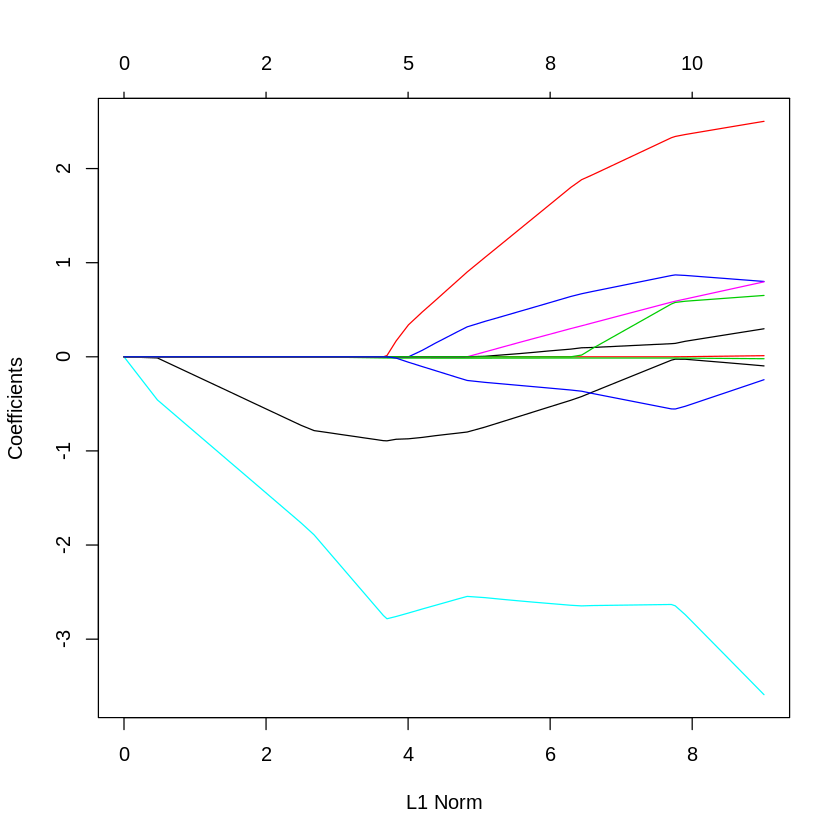

In [54]:
fit <- glmnet(as.matrix(mtcars[-1]), mtcars$mpg, alpha=1)

plot(fit)

In [55]:
lambda_vals <-rev(seq(0.0001, 0.03, by = 0.0001))
ajus.ridge <- cv.glmnet(scaled_data, train_Y, gamma = seq(from = 0, to= 1, by= 0.1),
                                                                   relax= TRUE, lambda = lambda_vals)
#ajus.ridge<- cv.glmnet(scaled_data, train_Y)
plot(ajus.ridge)

ERROR: Error in glmnet(x, y, weights = weights, offset = offset, lambda = lambda, : unused arguments (gamma = seq(from = 0, to = 1, by = 0.1), relax = TRUE)


In [53]:
model <- glmnet(scaled_data, train_Y, lambda= 0.011, alpha = 0.15)
#sum((predict(model, scaled_data) - train_Y) ^ 2) / nrow(scaled_data)


#summary(lm(train_Y~., data= X_means_train))


#summary(lm(train_Y~., data= train_X))


# forward, elegir con pca, elegir con lasso(coef que se anulan),
# tomar de a medias: cv para number_divisions, 
# eliminar las mas correlacionadas,   


In [13]:
corr_matrix <- cor(X_means_train, method = "pearson")
#corr_matrix

# Funcion para eliminar mas correlacionadas

In [9]:
# Elimina las variables con correlacion mayor a max_corr_acepted
# Retorna el dataframe con las variables nuevas. 
eliminate_variables_high_corr <- function(vasijas_X, max_corr_acepted) {
  new_vasijas_X <- vasijas_X
  are_variables_high_corr <- TRUE
  while (are_variables_high_corr) {
    corr_matrix <- cor(new_vasijas_X, method = "pearson")
    i <- 2
    loop_not_finished <- TRUE
    while (i <= ncol(new_vasijas_X) && loop_not_finished) {
      j <- 1
      while (j <= (i-1) && loop_not_finished) {
        if (corr_matrix[i, j] >= max_corr_acepted) {
          new_vasijas_X <- subset(new_vasijas_X, select = -i)
          loop_not_finished <- FALSE
        }
        if (i == nrow(corr_matrix) && j == nrow(corr_matrix) - 1) {
          are_variables_high_corr <- FALSE
        }
        j <- j + 1
      }
      i <- i + 1
    }
  }
  return(new_vasijas_X)
}
#new_vasijas_X <- eliminate_variables_high_corr(vasijas_X, 0.99)
#corr_matrix <- cor(vasijas_X, method = "pearson")
#write.csv(new_vasijas_X, "VesselSelectedFeatures_X.csv")